# Modulación M-PSK


In [9]:
#importamos las librerías necesarias
import numpy as np
import matplotlib.pyplot as plt

In [10]:
#Se definen parámetros 
Num_intervalos=5
#Probabilidad del bits
p0 = 0.5
p1 = 1-p0
#Parámetros de modulación M-PSK
formato='unipolar' 
N=0# 0,1
M=8
n = int(np.log2(M))
Ts = 0.001
fs=1/Ts
# parámetros

#parámetros para la gráfica de señales
fmuestreo = 1000000
fc = 10000
Ac=1

#Número de bits de la secuencia a generar
Nun_sec=Num_intervalos*n

In [11]:
def generador_secuencia(n, p0, p1, semilla=None):
    # validación
    if not np.isclose(p0 + p1, 1):
        raise ValueError("Las probabilidades deben cumplir: p0 + p1 = 1")
    rng = np.random.default_rng(semilla)
    return rng.choice([0, 1], size=n, p=[p0, p1])

# ejemplo
secuencia = generador_secuencia(Nun_sec, p0, p1, semilla=42)
print(f"Secuencia generada: {secuencia}")

Secuencia generada: [1 0 1 1 0 1 1 1 0 0 0 1 1 1 0]


In [12]:
def gray_code(n):
    """Genera códigos Gray de n bits"""
    if n == 0:
        return ['']
    prev = gray_code(n-1)
    return ['0' + code for code in prev] + ['1' + code for code in reversed(prev)]

## Convertidor de Datos M-PSK

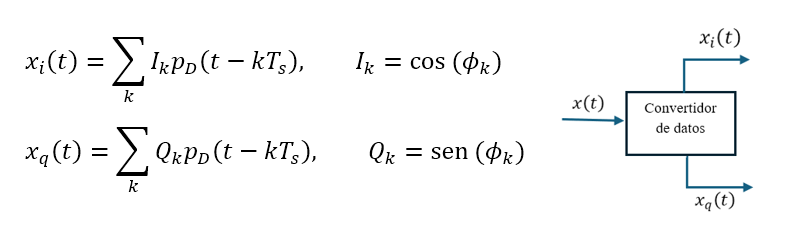

In [13]:
def convertidor_datos_psk(bits, M=4, N=0):
    n = int(np.log2(M))
    
    # asegurar múltiplo de n
    L = len(bits)
    if L % n != 0:
        bits = bits[:L - (L % n)]
    
    # agrupar bits
    grupos = bits.reshape(-1, n)
    
    # generar código Gray
    gray = gray_code(n)
    
    # mapping: binario -> índice Gray
    mapping = {tuple(int(b) for b in gray[i]): i for i in range(M)}
    
    # convertir grupos a índices b_k
    bk = [mapping[tuple(grupo)] for grupo in grupos]
    bk = np.array(bk)
    
    # calcular fases: φ_k = π(2*b_k + N)/M
    phi_k = np.pi * (2*bk + N) / M
    
    # calcular componentes I_k y Q_k
    Ik = np.cos(phi_k)
    Qk = np.sin(phi_k)
    
    # crear tabla de correspondencia
    tabla = {}
    for i, code in enumerate(gray):
        b = i
        phi = np.pi * (2*b + N) / M
        I = np.cos(phi)
        Q = np.sin(phi)
        tabla[code] = {'bk': b, 'phi_k': phi, 'Ik': I, 'Qk': Q}
    
    return Ik, Qk, bk, tabla


# Convertir datos
Ik, Qk, bk, tabla = convertidor_datos_psk(secuencia, M, N)

# Mostrar tabla de correspondencia
print("Tabla de correspondencia M-PSK:")
print(f"{'Gray':<10} {'bk':<5} {'phi_k':<15} {'Ik=cos(phi_k)':<15} {'Qk=sen(phi_k)':<15}")
print("-" * 70)
for gray_code_str, valores in tabla.items():
    print(f"{gray_code_str:<10} {valores['bk']:<5} {valores['phi_k']:<15.4f} {valores['Ik']:<15.4f} {valores['Qk']:<15.4f}")

print(f"\nPrimeros 20 símbolos Ik: {Ik[:20]}")
print(f"Primeros 20 símbolos Qk: {Qk[:20]}")

Tabla de correspondencia M-PSK:
Gray       bk    phi_k           Ik=cos(phi_k)   Qk=sen(phi_k)  
----------------------------------------------------------------------
000        0     0.0000          1.0000          0.0000         
001        1     0.7854          0.7071          0.7071         
011        2     1.5708          0.0000          1.0000         
010        3     2.3562          -0.7071         0.7071         
110        4     3.1416          -1.0000         0.0000         
111        5     3.9270          -0.7071         -0.7071        
101        6     4.7124          -0.0000         -1.0000        
100        7     5.4978          0.7071          -0.7071        

Primeros 20 símbolos Ik: [-1.83697020e-16 -1.83697020e-16 -1.00000000e+00  7.07106781e-01
 -1.00000000e+00]
Primeros 20 símbolos Qk: [-1.00000000e+00 -1.00000000e+00  1.22464680e-16  7.07106781e-01
  1.22464680e-16]



# La señal modulada M-PSK se puede expresar como:

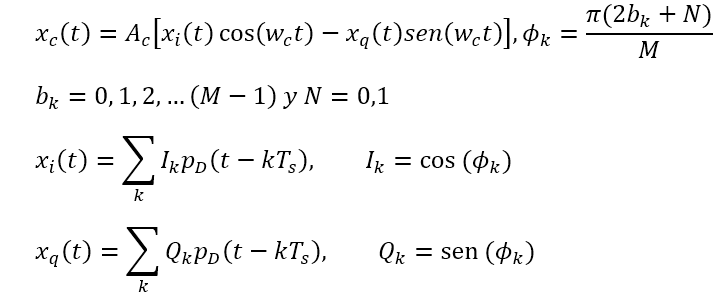

In [14]:
def pulso_rectangular(t, Ts, fmuestreo):
    """Genera un pulso rectangular de duración Ts"""
    eps = 1/(2*fmuestreo)
    return np.where((t >= -eps) & (t < Ts - eps), 1.0, 0.0)


def generar_xi(simbolos_I, Ts, fmuestreo):
    """
    Genera la señal en fase xi(t) = Σ_k I_k · p_D(t - k·T_s)
    """
    Ns = int(Ts * fmuestreo)
    t = np.arange(len(simbolos_I) * Ns) / fmuestreo
    xi_t = np.zeros_like(t, dtype=float)
    
    for k, I_k in enumerate(simbolos_I):
        xi_t += I_k * pulso_rectangular(t - k*Ts, Ts, fmuestreo)
    
    return t, xi_t


def generar_xq(simbolos_Q, Ts, fmuestreo):
    """
    Genera la señal en cuadratura xq(t) = Σ_k Q_k · p_D(t - k·T_s)
    """
    Ns = int(Ts * fmuestreo)
    t = np.arange(len(simbolos_Q) * Ns) / fmuestreo
    xq_t = np.zeros_like(t, dtype=float)
    
    for k, Q_k in enumerate(simbolos_Q):
        xq_t += Q_k * pulso_rectangular(t - k*Ts, Ts, fmuestreo)
    
    return t, xq_t


# Generar señales para los primeros 20 símbolos
num_simbolos = 20
t, x_i = generar_xi(Ik[:num_simbolos], Ts, fmuestreo)
_, x_q = generar_xq(Qk[:num_simbolos], Ts, fmuestreo)

# Pulso rectangular (para graficar)
pulso_rect = pulso_rectangular(t, Ts, fmuestreo)

# Portadoras
wc = 2 * np.pi * fc
portadora_cos = np.cos(wc * t)
portadora_sin = -np.sin(wc * t)

# Productos de señales con portadoras
xi_cos = x_i * portadora_cos
xq_sin = -x_q * np.sin(wc * t)

# Señal modulada: x_c(t) = A_c[x_q(t)cos(w_c·t) - x_i(t)sin(w_c·t)]
x_c = Ac * (x_i * portadora_cos - x_q * np.sin(wc * t))

print(f"Señales generadas exitosamente para {num_simbolos} símbolos")
print(f"Duración total: {t[-1]:.6f} segundos")
print(f"Número de muestras: {len(t)}")

Señales generadas exitosamente para 20 símbolos
Duración total: 0.004999 segundos
Número de muestras: 5000


In [15]:
# Obtener la secuencia de códigos Gray para cada símbolo
def obtener_gray_secuencia(bits, M):
    """Retorna la secuencia de códigos Gray correspondientes a los símbolos"""
    n = int(np.log2(M))
    L = len(bits)
    if L % n != 0:
        bits = bits[:L - (L % n)]
    
    grupos = bits.reshape(-1, n)
    gray = gray_code(n)
    mapping = {tuple(int(b) for b in gray[i]): i for i in range(M)}
    
    # Obtener códigos Gray para cada símbolo
    gray_secuencia = []
    for grupo in grupos:
        # Encontrar el código Gray correspondiente
        for code in gray:
            if mapping[tuple(int(b) for b in code)] == mapping[tuple(grupo)]:
                gray_secuencia.append(code)
                break
    
    return gray_secuencia

# Obtener secuencia de códigos Gray
gray_secuencia = obtener_gray_secuencia(secuencia, M)
print(f"dsecuencia Gray: {gray_secuencia[:num_simbolos]}")

dsecuencia Gray: ['101', '101', '110', '001', '110']


In [ ]:

print(f"Secuencia generada: {secuencia}")
print(f"\nPrimeros 20 símbolos Ik: {Ik[:20]}")
print(f"Primeros 20 símbolos Qk: {Qk[:20]}")
# Mostrar tabla de correspondencia
print("Tabla de correspondencia M-PSK:")
print(f"{'Gray':<10} {'bk':<5} {'phi_k':<15} {'Ik=cos(phi_k)':<15} {'Qk=sen(phi_k)':<15}")
print("-" * 70)
for gray_code_str, valores in tabla.items():
    print(f"{gray_code_str:<10} {valores['bk']:<5} {valores['phi_k']:<15.4f} {valores['Ik']:<15.4f} {valores['Qk']:<15.4f}")

    
# Gráficos de las formas de onda con anotaciones de códigos Gray
plt.figure(figsize=(12, 20))

# 1. Pulso rectangular
plt.subplot(8, 1, 1)
plt.step(t, pulso_rect, where='post', color='#0015FA', linewidth=1.5)
plt.fill_between(t, pulso_rect, color='#0015FA', alpha=0.3)
plt.title("Pulso Rectangular p_D(t) de duración Ts")
plt.ylabel('Amplitud')
plt.grid(True, alpha=0.3)
plt.xlim([0, t[-1]])

# 2. Señal en fase xi(t) con códigos Gray
ax2 = plt.subplot(8, 1, 2)
plt.step(t, x_i, where='post', color='#09F700', linewidth=1.5)
plt.fill_between(t, x_i, color='#09F700', alpha=0.3)
plt.title("Señal en fase: xi(t)")
plt.ylabel('Amplitud')
plt.grid(True, alpha=0.3)
plt.xlim([0, t[-1]])
# Añadir códigos Gray
for k in range(min(len(gray_secuencia), num_simbolos)):
    if k < len(Ik):
        t_pos = (k + 0.5) * Ts  # Posición en el centro del intervalo
        y_pos = Ik[k] + 0.15 if Ik[k] >= 0 else Ik[k] - 0.2  # Posición vertical
        plt.text(t_pos, y_pos, gray_secuencia[k], ha='center', va='bottom', 
                fontsize=8, bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

# 3. Señal en cuadratura xq(t) con códigos Gray
ax3 = plt.subplot(8, 1, 3)
plt.step(t, x_q, where='post', color='#09F700', linewidth=1.5)
plt.fill_between(t, x_q, color='#09F700', alpha=0.3)
plt.title("Señal en cuadratura: xq(t)")
plt.ylabel('Amplitud')
plt.grid(True, alpha=0.3)
plt.xlim([0, t[-1]])
# Añadir códigos Gray
for k in range(min(len(gray_secuencia), num_simbolos)):
    if k < len(Qk):
        t_pos = (k + 0.5) * Ts
        y_pos = Qk[k] + 0.15 if Qk[k] >= 0 else Qk[k] - 0.2
        plt.text(t_pos, y_pos, gray_secuencia[k], ha='center', va='bottom',
                fontsize=8, bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

# 4. Portadoras: cos(wc·t) y -sin(wc·t)
plt.subplot(8, 1, 4)
plt.plot(t, portadora_cos, color='blue', linewidth=1.2, label='cos(wc·t)', alpha=0.8)
plt.plot(t, portadora_sin, color='red', linewidth=1.2, label='-sin(wc·t)', alpha=0.8)
plt.title("Portadoras: cos(wc·t) y -sin(wc·t)")
plt.ylabel('Amplitud')
plt.grid(True, alpha=0.3)
plt.legend(loc='upper right')
plt.xlim([0, t[-1]])

# 5. Producto xi(t)cos(wc·t)
plt.subplot(8, 1, 5)
plt.plot(t, xi_cos, color='blue', linewidth=0.8)
plt.title("Producto: xi(t)·cos(wc·t)")
plt.ylabel('Amplitud')
plt.grid(True, alpha=0.3)
plt.xlim([0, t[-1]])

# 6. Producto -xq(t)sin(wc·t)
plt.subplot(8, 1, 6)
plt.plot(t, xq_sin, color='red', linewidth=0.8)
plt.title("Producto: -xq(t)·sin(wc·t)")
plt.ylabel('Amplitud')
plt.grid(True, alpha=0.3)
plt.xlim([0, t[-1]])

# 7. Suma de productos (componentes de xc(t))
plt.subplot(8, 1, 7)
plt.plot(t, xi_cos, color='blue', linewidth=0.8, alpha=0.9, label='xi(t)·cos(wc·t)')
plt.plot(t, xq_sin, color='red', linewidth=0.8, alpha=0.9, label='-xq(t)·sin(wc·t)')
plt.title(f"Componentes de la señal modulada")
plt.ylabel('Amplitud')
plt.legend(loc='upper right', fontsize=8)
plt.xlim([0, t[-1]])

# 8. Señal modulada con códigos Gray
ax8 = plt.subplot(8, 1, 8)
plt.plot(t, xi_cos + xq_sin, color='#000000', linewidth=1.2, label='Suma')
plt.title(f"Señal Modulada {M}-PSK")
plt.ylabel('Amplitud')
plt.legend(loc='upper right', fontsize=8)
plt.xlim([0, t[-1]])
# Añadir códigos Gray en la señal modulada (abajo)
y_max = np.max(xi_cos + xq_sin)
y_min = np.min(xi_cos + xq_sin)
y_range = y_max - y_min
for k in range(min(len(gray_secuencia), num_simbolos)):
    t_pos = (k + 0.5) * Ts
    # Posicionar en la parte inferior del gráfico
    y_pos = y_min - 0.15 * y_range
    plt.text(t_pos, y_pos, gray_secuencia[k], ha='center', va='top',
            fontsize=8, bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))

plt.tight_layout()
plt.show()

Secuencia generada: [1 0 1 1 0 1 1 1 0 0 0 1 1 1 0]

Primeros 20 símbolos Ik: [-1.83697020e-16 -1.83697020e-16 -1.00000000e+00  7.07106781e-01
 -1.00000000e+00]
Primeros 20 símbolos Qk: [-1.00000000e+00 -1.00000000e+00  1.22464680e-16  7.07106781e-01
  1.22464680e-16]
Tabla de correspondencia M-PSK:
Gray       bk    phi_k           Ik=cos(phi_k)   Qk=sen(phi_k)  
----------------------------------------------------------------------
000        0     0.0000          1.0000          0.0000         
001        1     0.7854          0.7071          0.7071         
011        2     1.5708          0.0000          1.0000         
010        3     2.3562          -0.7071         0.7071         
110        4     3.1416          -1.0000         0.0000         
111        5     3.9270          -0.7071         -0.7071        
101        6     4.7124          -0.0000         -1.0000        
100        7     5.4978          0.7071          -0.7071        
